# Comparación: Datos normales vs. no normales

Este notebook compara dos conjuntos de datos artificiales: uno con distribución normal y otro con distribución sesgada, para observar las diferencias en visualización y pruebas estadísticas de normalidad.

### **¿Por qué es importante checar la normalidad?**

Muchos métodos estadísticos echan mano de la media y la varianza para realizar inferencias. Si los datos no son normales (por ejemplo, si están fuertemente sesgados o tienen colas pesadas), ocurren dos problemas principales:

- Inexactitud en pruebas de hipótesis: Los valores p (p-values) calculados y los intervalos de confianza dejan de ser confiables, lo que puede llevar a falsos positivos o falsos negativos.

- Inestabilidad en la optimización: En algoritmos de aprendizaje automático, la falta de normalidad o la presencia de valores atípicos (outliers) pueden hacer que los métodos de optimización (como el descenso de gradiente) tarden mucho más en converger o se queden atrapados en soluciones subóptimas.

### **¿Para qué modelos se necesita?**

El supuesto de normalidad no siempre se aplica directamente a los datos de entrada (X), sino que a veces se exige en los errores o residuos del modelo.

**A. Modelos estadísticos clásicos**

- Regresión Lineal Múltiple (MCO): Ojo aquí, un error común es pensar que las variables X o Y deben ser normales. El supuesto real es que los residuos (los errores) del modelo deben distribuirse de forma normal e∼N(0,σ2). Si no se cumple, los intervalos de confianza de los coeficientes β y las pruebas t o F no serán válidos.

- ANOVA (Análisis de Varianza): Requiere que la variable dependiente se distribuya normalmente dentro de cada uno de los grupos que se están comparando.

- Prueba t de Student (para una o dos muestras): Asume que las poblaciones de origen son normales, especialmente si el tamaño de la muestra es pequeño (n<30).

**B. Algoritmos de Machine Learning (Sensibles a la distribución)**

Aunque los modelos de Machine Learning no "vuelan en pedazos" formalmente sin normalidad, su rendimiento mejora drásticamente si las variables de entrada se aproximan a una Gaussiana:

- Análisis de Discriminante Lineal (LDA) y QDA: Asumen explícitamente que las variables predictoras siguen una distribución normal multivariante dentro de cada clase.

- Modelos basados en distancias o gradientes (Regresión Ridge/Lasso, Redes Neuronales, SVM, K-Means): Se ven fuertemente afectados por distribuciones sesgadas. Aunque no exigen normalidad estricta, se benefician enormemente de transformaciones que estabilicen la varianza (como escalado estándar, transformaciones Log o Box-Cox) para evitar que variables con escalas o sesgos masivos dominen el modelo.

**Nota de alivio:** Los modelos basados en árboles de decisión (como Random Forest o XGBoost) son completamente invariantes a la distribución de las variables de entrada; a ellos no les afecta en absoluto el sesgo.



### **¿Qué pruebas de normalidad existen?**

Las herramientas para verificar la normalidad se dividen en dos categorías: gráficas (intuitivas y visuales) y analíticas/formales (pruebas de hipótesis).

**A. Pruebas gráficas (Las más recomendadas en la práctica)**

A veces las pruebas estadísticas son demasiado sensibles con muestras grandes. Por ello, el análisis visual suele ser el mejor punto de partida.

- Gráfico Q-Q (Quantile-Quantile Plot): Grafica los cuantiles de tus datos frente a los cuantiles teóricos de una distribución normal. Si tus datos son normales, los puntos caerán casi alineados sobre una línea recta de 45 grados. Si se curvan en las esquinas, exponen el sesgo o las colas pesadas.

- Histograma con curva KDE: Permite ver de forma directa si los datos simulan la campana de Gauss o si presentan asimetría y multimodalidad.

**B. Pruebas estadísticas formales**

Todas estas pruebas manejan la misma hipótesis:

    H0​: Los datos provienen de una distribución normal.
    H1​: Los datos no provienen de una distribución normal.
    (Por lo tanto, buscamos un p-value>0.05 para mantener la hipótesis de normalidad).

![image.png](attachment:image.png)

### Pruebas estadísticas y asimetría

Media normales: 49.55, Media sesgados: 10.47


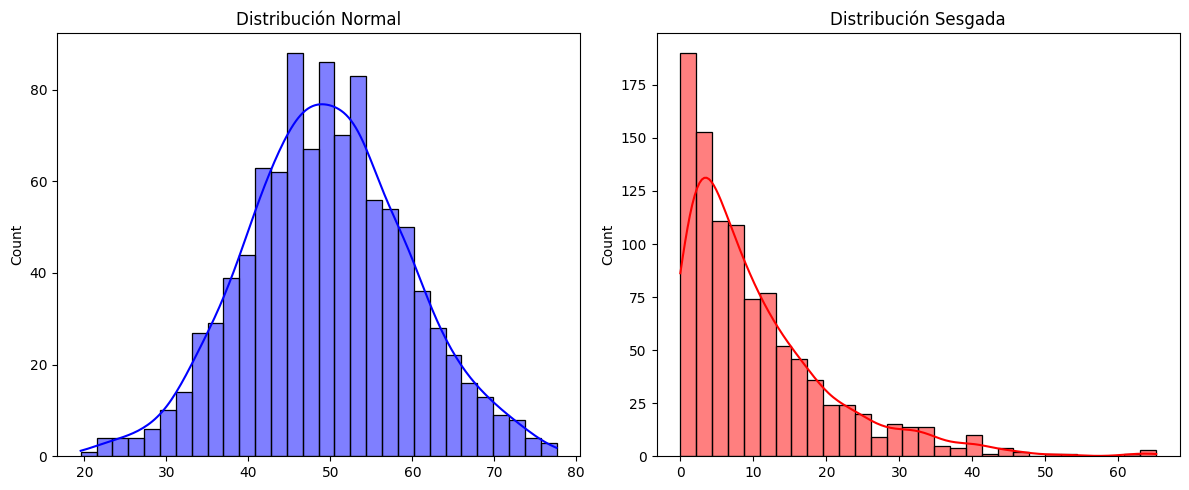

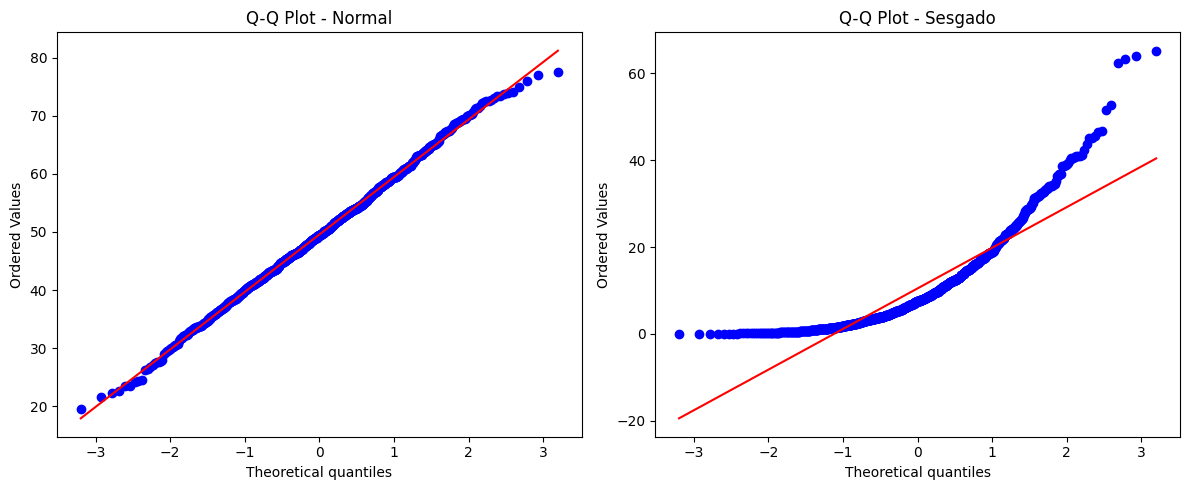

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, skew, kurtosis, probplot

# Generar datos
np.random.seed(0)
normales = np.random.normal(loc=50, scale=10, size=1000)
sesgados = np.random.exponential(scale=10, size=1000)

print(f"Media normales: {np.mean(normales):.2f}, Media sesgados: {np.mean(sesgados):.2f}")
## Visualización: Histograma y KDE
# Comparar histogramas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(normales, kde=True, bins=30, color='blue')
plt.title("Distribución Normal")

plt.subplot(1, 2, 2)
sns.histplot(sesgados, kde=True, bins=30, color='red')
plt.title("Distribución Sesgada")

plt.tight_layout()
plt.show()
## Q-Q Plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
probplot(normales, dist="norm", plot=plt)
plt.title("Q-Q Plot - Normal")

plt.subplot(1, 2, 2)
probplot(sesgados, dist="norm", plot=plt)
plt.title("Q-Q Plot - Sesgado")

plt.tight_layout()
plt.show()

In [ ]:
# Shapiro-Wilk
sn_stat, sn_p = shapiro(normales)
ss_stat, ss_p = shapiro(sesgados)

print("Datos normales:")
print(f"  p-valor Shapiro: {sn_p:.4f}")
print(f"  Asimetría: {skew(normales):.3f}, Curtosis: {kurtosis(normales):.3f}\n")

print("Datos sesgados:")
print(f"  p-valor Shapiro: {ss_p:.4f}")
print(f"  Asimetría: {skew(sesgados):.3f}, Curtosis: {kurtosis(sesgados):.3f}")

Datos normales:
  p-valor Shapiro: 0.5916
  Asimetría: 0.034, Curtosis: -0.047

Datos sesgados:
  p-valor Shapiro: 0.0000
  Asimetría: 1.741, Curtosis: 3.833


## Conclusión
- Los datos **normales** tienen forma de campana, Q-Q plot alineado, asimetría ≈ 0, y **no se rechaza** la normalidad.
- Los datos **sesgados** muestran cola larga, curva asimétrica, Q-Q plot curvado, y **se rechaza** la normalidad con Shapiro.